
# Medical Aid Reviews Analysis

## ST10500865 Kamogelo Motau

**Dataset:** HelloPeter Medical Aid Reviews  
**Records:** 4,965 Reviews  
**Companies:** Affinity Health and Bonitas Medical Fund

## Objectives
1. Identify major customer concerns using Topic Modelling.
2. Analyse customer sentiment using Machine Learning.
3. Provide business recommendations.


In [1]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import LatentDirichletAllocation

pd.set_option('display.max_columns', None)


## Load and Inspect Data

In [2]:

df = pd.read_csv('reviews.csv')

print('Rows, Columns:', df.shape)
df.head()


Rows, Columns: (4965, 27)


,id,user_id,created_at,authorDisplayName,author,authorAvatar,author_id,review_title,review_rating,review_content,business_name,business_slug,permalink,replied,messages,business_logo,industry_logo,industry_name,industry_slug,status_id,nps_rating,source,is_reported,business_reporting,author_created_date,author_total_reviews_count,attachments
0,4221151,34bb63e0-3ff4-11ed-95bb-65c5ab998749,2022/12/12 08:14,Gabisile I,Gabisile I,NaN,34bb63e0-3ff4-11ed-95bb-65c5ab998749,Customer Service Unavailability on Weekends Ni...,1,I was extremely dissapointed! I had to go get ...,Affinity Health,affinity-health,customer-service-unavailability-on-weekends-ni...,1,"[{'id': 2445085, 'body': '<div>Good Morning Ga...",https://s3-us-west-2.amazonaws.com/hp-cdn-01/u...,/static/img/industries/icons/medical-aid-icon.jpg,Medical Aid,medical-aid,1,NaN,WEBSITE,False,NaN,2022/09/29,2,[]
1,4220685,30bcca00-cab3-11ec-97b2-85386ab37ffe,2022/12/11 09:48,Ashley J,Ashley J,NaN,30bcca00-cab3-11ec-97b2-85386ab37ffe,Endless waiting,1,The service of this medical aid is getting so ...,Affinity Health,affinity-health,endless-waiting-133913fe9d5ee40fa1a7f1e5c573d7...,1,"[{'id': 2444570, 'body': '<div>Good Day&nbsp; ...",https://s3-us-west-2.amazonaws.com/hp-cdn-01/u...,/static/img/industries/icons/medical-aid-icon.jpg,Medical Aid,medical-aid,1,NaN,WEBSITE,False,NaN,2022/05/03,3,[]
2,4219832,6cf94950-e2bb-11ec-867d-8ffbe4aec603,2022/12/09 19:31,Leeanne L,Leeanne L,NaN,6cf94950-e2bb-11ec-867d-8ffbe4aec603,Bad service,1,WORSE MEDICAL INSURANCE EVER!!! They cover not...,Affinity Health,affinity-health,bad-service-772d268e350b86254f15d0550fd663d473...,1,"[{'id': 2443718, 'body': '<div>Good Day Leeann...",https://s3-us-west-2.amazonaws.com/hp-cdn-01/u...,/static/img/industries/icons/medical-aid-icon.jpg,Medical Aid,medical-aid,1,NaN,WEBSITE,False,NaN,2022/06/02,1,[]
3,4218030,97c56d80-7707-11ed-992c-c7bfb27375ff,2022/12/08 17:06,Helgard B,Helgard B,NaN,97c56d80-7707-11ed-992c-c7bfb27375ff,Worst medical insurance,1,USELESS!!! What a waste of money. It's better ...,Affinity Health,affinity-health,worst-medical-insurance-ded26cfdeebc7cde4d1145...,1,"[{'id': 2443493, 'body': '<div>Good Day Helgar...",https://s3-us-west-2.amazonaws.com/hp-cdn-01/u...,/static/img/industries/icons/medical-aid-icon.jpg,Medical Aid,medical-aid,1,NaN,WEBSITE,False,NaN,2022/12/08,2,[]
4,4214885,ccf30640-c466-11ec-8d64-e905cb39bf25,2022/12/07 08:48,Gordon T,Gordon T,NaN,ccf30640-c466-11ec-8d64-e905cb39bf25,STAY AWAY!,1,STAY AWAY!! You will spend more time pre-autho...,Affinity Health,affinity-health,stay-away-3476c462554b5c84b9743db67659383e8477...,1,"[{'id': 2438868, 'body': '<div>Good Day Gordon...",https://s3-us-west-2.amazonaws.com/hp-cdn-01/u...,/static/img/industries/icons/medical-aid-icon.jpg,Medical Aid,medical-aid,1,0.0,WEBSITE,False,NaN,2022/04/25,1,[]


In [3]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4965 entries, 0 to 4964
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          4965 non-null   int64  
 1   user_id                     4965 non-null   object 
 2   created_at                  4965 non-null   object 
 3   authorDisplayName           4965 non-null   object 
 4   author                      4965 non-null   object 
 5   authorAvatar                20 non-null     object 
 6   author_id                   4965 non-null   object 
 7   review_title                4963 non-null   object 
 8   review_rating               4965 non-null   int64  
 9   review_content              4965 non-null   object 
 10  business_name               4965 non-null   object 
 11  business_slug               4965 non-null   object 
 12  permalink                   4965 non-null   object 
 13  replied                     4965 

In [4]:

df.isnull().sum().sort_values(ascending=False)


authorAvatar                  4945
business_reporting            4918
nps_rating                    3777
source                        1389
review_title                     2
id                               0
business_logo                    0
author_total_reviews_count       0
author_created_date              0
is_reported                      0
status_id                        0
industry_slug                    0
industry_name                    0
industry_logo                    0
replied                          0
messages                         0
user_id                          0
permalink                        0
business_slug                    0
business_name                    0
review_content                   0
review_rating                    0
author_id                        0
author                           0
authorDisplayName                0
created_at                       0
attachments                      0
dtype: int64

## Dataset Variables Selected

In [5]:

columns_needed = [
    'review_title',
    'review_content',
    'review_rating',
    'business_name',
    'created_at'
]

reviews = df[columns_needed].copy()
reviews.head()


,review_title,review_content,review_rating,business_name,created_at
0,Customer Service Unavailability on Weekends Ni...,I was extremely dissapointed! I had to go get ...,1,Affinity Health,2022/12/12 08:14
1,Endless waiting,The service of this medical aid is getting so ...,1,Affinity Health,2022/12/11 09:48
2,Bad service,WORSE MEDICAL INSURANCE EVER!!! They cover not...,1,Affinity Health,2022/12/09 19:31
3,Worst medical insurance,USELESS!!! What a waste of money. It's better ...,1,Affinity Health,2022/12/08 17:06
4,STAY AWAY!,STAY AWAY!! You will spend more time pre-autho...,1,Affinity Health,2022/12/07 08:48


## Missing Values and Duplicates

In [6]:

print('Missing Values')
print(reviews.isnull().sum())

print('\nDuplicates')
print(reviews.duplicated().sum())


Missing Values
review_title      2
review_content    0
review_rating     0
business_name     0
created_at        0
dtype: int64

Duplicates
0


In [7]:

reviews = reviews.drop_duplicates()
reviews = reviews.dropna(subset=['review_content'])


## Rating Distribution

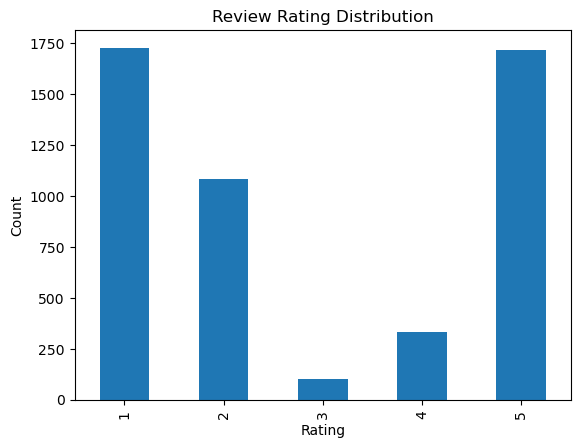

In [8]:

reviews['review_rating'].value_counts().sort_index().plot(kind='bar')

plt.title('Review Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('Review_Rating_Distribution.png')
plt.show()


## Reviews by Medical Aid

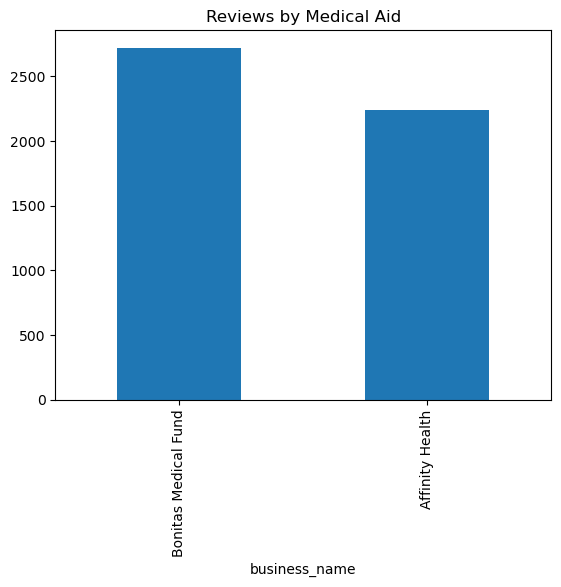

In [9]:

reviews['business_name'].value_counts().plot(kind='bar')

plt.title('Reviews by Medical Aid')
plt.savefig('Reviews_by_Medical_Aid.png')
plt.show()


## Create Sentiment Labels

In [10]:

def sentiment(rating):

    if rating <= 2:
        return 'Negative'

    elif rating == 3:
        return 'Neutral'

    else:
        return 'Positive'

reviews['sentiment'] = reviews['review_rating'].apply(sentiment)

reviews['sentiment'].value_counts()


sentiment
Negative    2813
Positive    2050
Neutral      102
Name: count, dtype: int64

## Text Preparation

In [11]:

reviews['text'] = (
    reviews['review_title'].astype(str)
    + ' '
    + reviews['review_content'].astype(str)
)


In [12]:

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text

reviews['clean_text'] = reviews['text'].apply(clean_text)

reviews[['text','clean_text']].head()


,text,clean_text
0,Customer Service Unavailability on Weekends Ni...,customer service unavailability on weekends ni...
1,Endless waiting The service of this medical ai...,endless waiting the service of this medical ai...
2,Bad service WORSE MEDICAL INSURANCE EVER!!! Th...,bad service worse medical insurance ever they ...
3,Worst medical insurance USELESS!!! What a wast...,worst medical insurance useless what a waste o...
4,STAY AWAY! STAY AWAY!! You will spend more tim...,stay away stay away you will spend more time p...


## Review Length Analysis

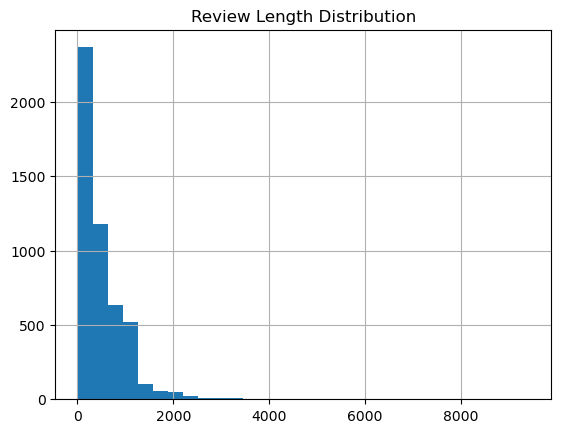

In [13]:

reviews['review_length'] = reviews['clean_text'].apply(len)

reviews['review_length'].hist(bins=30)

plt.title('Review Length Distribution')
plt.savefig('Review_Length_Distribution.png')
plt.show()


## TF-IDF Feature Engineering

In [14]:

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=5
)

X = tfidf.fit_transform(reviews['clean_text'])

y = reviews['sentiment']


## Train/Test Split

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Logistic Regression Model

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced'
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)


In [17]:

accuracy = accuracy_score(y_test, predictions)

print('Accuracy:', round(accuracy,4))
print('\n')
print(classification_report(y_test,predictions))


Accuracy: 0.9416


              precision    recall  f1-score   support

    Negative       0.95      0.98      0.96       563
     Neutral       0.07      0.05      0.06        20
    Positive       0.96      0.93      0.95       410

    accuracy                           0.94       993
   macro avg       0.66      0.65      0.66       993
weighted avg       0.94      0.94      0.94       993



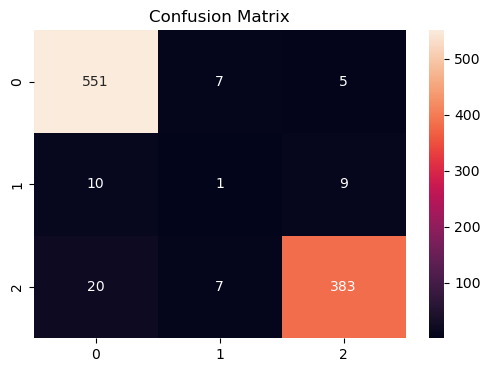

In [18]:

cm = confusion_matrix(y_test,predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.savefig('Confusion_Matrix.png')
plt.show()


## Most Important Predictive Words

In [19]:

feature_names = tfidf.get_feature_names_out()

for class_name, coef in zip(model.classes_, model.coef_):

    top = np.argsort(coef)[-10:]

    print('\n', class_name)

    print(feature_names[top])



 Negative
['cover' 'useless' 'pathetic' 'number' 'sent' 'br' 'money' 'dont' 'worst'
 'told']

 Neutral
['regarding' 'sydne' 'leighann' 'scan' 'service thuthuka' 'wheelchair'
 'health great' 'lancet' 'ppn' 'servicep']

 Positive
['amazing' 'efficient' 'great' 'good' 'assisted' 'best' 'service'
 'excellent' 'helpful' 'thank']


## Topic Modelling (Areas of Concern)

In [20]:

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=3000
)

topic_matrix = vectorizer.fit_transform(
    reviews['clean_text']
)

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(topic_matrix)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [21]:

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):

    print('\nTopic', topic_idx + 1)

    words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(words)



Topic 1
['affinity', 'health', 'medication', 'pharmacy', 'service', 'direct', 'dont', 'policy', 'money', 'chronic']

Topic 2
['bonitas', 'medical', 'aid', 'service', 'time', 'im', 'claim', 'dont', 'claims', 'just']

Topic 3
['hospital', 'pay', 'medical', 'bonitas', 'cover', 'doctor', 'claim', 'paid', 'aid', 'specialist']

Topic 4
['bonitas', 'br', 'email', 'received', 'account', 'sent', 'medical', 'payment', 'aid', 'paid']

Topic 5
['service', 'thank', 'great', 'excellent', 'affinity', 'good', 'helpful', 'health', 'friendly', 'customer']



# Interpretation Section

After running the notebook:

## Sentiment Findings
- Identify whether reviews are mostly positive or negative.
- Examine the confusion matrix and classification report.

## Topic Findings
Common topics are expected to include:
- Customer service
- Claims processing
- Authorisations
- Medication coverage
- Waiting times

## Business Recommendations
1. Improve response times.
2. Simplify authorisation procedures.
3. Improve claims communication.
4. Increase customer support availability.
5. Provide proactive status updates to members.
